# 05 Phase 2 Robustness Analysis

This notebook evaluates whether the main conclusions from Phase 2 are robust to data splitting, study-level grouping, feature removal, target definition, and mechanism subgrouping.

The goal is not to maximize predictive performance, but to test whether the modeling conclusions are stable.

In [3]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit, GroupKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [4]:
# Load data and define Phase 2 variables
df = pd.read_csv(
    "../data/processed/hydrovoltaic_dataset_phase2_input_utf8.csv",
    encoding="utf-8-sig"
)

TARGET = "log_estimated_power_density"
STRATIFY_COL = "mechanism_simple"
GROUP_COL = "paper_doi"

FEATURES_MODEL_A = [
    "material_class",
    "structure_class",
    "built_in_asymmetry",
    "inorganic_electrolyte_present",
    "polyelectrolyte_present",
    "has_anionic",
    "has_cationic",
    "has_zwitterionic",
    "mechanism_simple",
    "water_interaction_mode",
    "top_electrode",
    "bottom_electrode",
    "electrode_symmetry",
    "metal_electrode",
    "ionic_groups",
    "ion_type"
]

FEATURES_MODEL_B = FEATURES_MODEL_A + [
    "log_internal_resistance_Mohm",
    "has_internal_resistance"
]

df_robust = df.dropna(subset=[TARGET, STRATIFY_COL]).copy()

print("Rows:", df_robust.shape[0])
print("Columns:", df_robust.shape[1])
print("\nMechanism counts:")
print(df_robust[STRATIFY_COL].value_counts(dropna=False))

print("\nModel B features:", len(FEATURES_MODEL_B))

Rows: 159
Columns: 52

Mechanism counts:
mechanism_simple
ion_gradient    107
streaming        52
Name: count, dtype: int64

Model B features: 18


In [5]:
# Preprocessor helper
def build_preprocessor(df_input, features, scale_numeric=False):
    categorical_features = []
    numeric_features = []

    for col in features:
        if pd.api.types.is_numeric_dtype(df_input[col]):
            numeric_features.append(col)
        else:
            categorical_features.append(col)

    if scale_numeric:
        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
    else:
        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ],
        remainder="drop"
    )

    return preprocessor

In [6]:
# Main model for robustness
def build_rf_pipeline(df_input, features):
    preprocessor = build_preprocessor(
        df_input=df_input,
        features=features,
        scale_numeric=False
    )

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", rf)
    ])

    return pipe

# Section 1 — Repeated Stratified ShuffleSplit

## 1. Stability under repeated stratified random splits

We first test whether model performance is stable under repeated random train/test splits while preserving the mechanism distribution.

In [7]:
# Repeated ShuffleSplit evaluation
X = df_robust[FEATURES_MODEL_B]
y = df_robust[TARGET]
strata = df_robust[STRATIFY_COL]

rf_pipeline = build_rf_pipeline(df_robust, FEATURES_MODEL_B)

sss = StratifiedShuffleSplit(
    n_splits=100,
    test_size=0.2,
    random_state=42
)

cv_result = cross_validate(
    rf_pipeline,
    X,
    y,
    cv=sss.split(X, strata),
    scoring={
        "r2": "r2",
        "neg_rmse": "neg_root_mean_squared_error",
        "neg_mae": "neg_mean_absolute_error"
    },
    n_jobs=-1
)

shuffle_summary = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Mean": [
        cv_result["test_r2"].mean(),
        -cv_result["test_neg_rmse"].mean(),
        -cv_result["test_neg_mae"].mean()
    ],
    "Std": [
        cv_result["test_r2"].std(),
        cv_result["test_neg_rmse"].std(),
        cv_result["test_neg_mae"].std()
    ],
    "Min": [
        cv_result["test_r2"].min(),
        -cv_result["test_neg_rmse"].max(),
        -cv_result["test_neg_mae"].max()
    ],
    "Max": [
        cv_result["test_r2"].max(),
        -cv_result["test_neg_rmse"].min(),
        -cv_result["test_neg_mae"].min()
    ]
})

shuffle_summary

,Metric,Mean,Std,Min,Max
0,R2,0.164450,0.178716,-0.332258,0.597337
1,RMSE,1.167129,0.163804,0.787857,1.633110
2,MAE,0.895920,0.124085,0.624545,1.315938


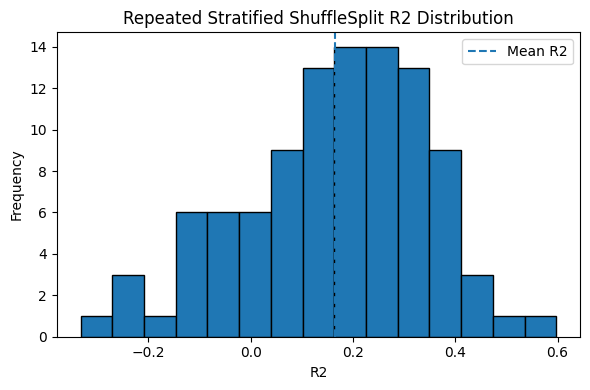

In [8]:
# R² distribution plot
plt.figure(figsize=(6, 4))
plt.hist(cv_result["test_r2"], bins=15, edgecolor="black")
plt.axvline(cv_result["test_r2"].mean(), linestyle="--", label="Mean R2")
plt.xlabel("R2")
plt.ylabel("Frequency")
plt.title("Repeated Stratified ShuffleSplit R2 Distribution")
plt.legend()
plt.tight_layout()
plt.show()

Repeated stratified ShuffleSplit provides a more conservative estimate of model performance compared to single cross-validation, with mean R² ≈ 0.16 and substantial variance across splits. This indicates that while the model captures a genuine predictive signal, the strength of this signal varies significantly across different data partitions.

Such behavior is consistent with the heterogeneous nature of the dataset, where certain subsets are more predictable than others. Therefore, model performance is primarily limited by data variability rather than model capacity.

## 05.2 Robustness across studies (Grouped CV)

To evaluate whether the model generalizes across different studies, we perform grouped cross-validation based on paper DOI. This ensures that samples from the same study do not appear in both training and test sets.

In [9]:
# Grouped CV
from sklearn.model_selection import GroupKFold

X = df_robust[FEATURES_MODEL_B]
y = df_robust[TARGET]
groups = df_robust[GROUP_COL]

rf_pipeline = build_rf_pipeline(df_robust, FEATURES_MODEL_B)

gkf = GroupKFold(n_splits=5)

group_cv_result = cross_validate(
    rf_pipeline,
    X,
    y,
    cv=gkf.split(X, y, groups),
    scoring={
        "r2": "r2",
        "neg_rmse": "neg_root_mean_squared_error",
        "neg_mae": "neg_mean_absolute_error"
    },
    n_jobs=-1
)

In [10]:
# 汇总结果
group_summary = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Mean": [
        group_cv_result["test_r2"].mean(),
        -group_cv_result["test_neg_rmse"].mean(),
        -group_cv_result["test_neg_mae"].mean()
    ],
    "Std": [
        group_cv_result["test_r2"].std(),
        group_cv_result["test_neg_rmse"].std(),
        group_cv_result["test_neg_mae"].std()
    ],
    "Min": [
        group_cv_result["test_r2"].min(),
        -group_cv_result["test_neg_rmse"].max(),
        -group_cv_result["test_neg_mae"].max()
    ],
    "Max": [
        group_cv_result["test_r2"].max(),
        -group_cv_result["test_neg_rmse"].min(),
        -group_cv_result["test_neg_mae"].min()
    ]
})

group_summary

,Metric,Mean,Std,Min,Max
0,R2,0.106480,0.197512,-0.147918,0.445348
1,RMSE,1.222474,0.161715,0.913516,1.377523
2,MAE,0.921210,0.098315,0.749280,1.025631


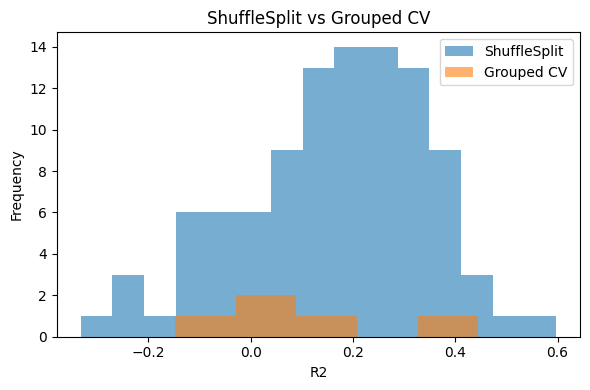

In [11]:
# 画一个R²对比图（很有用）
plt.figure(figsize=(6,4))

plt.hist(cv_result["test_r2"], bins=15, alpha=0.6, label="ShuffleSplit")
plt.hist(group_cv_result["test_r2"], bins=5, alpha=0.6, label="Grouped CV")

plt.xlabel("R2")
plt.ylabel("Frequency")
plt.legend()
plt.title("ShuffleSplit vs Grouped CV")
plt.tight_layout()
plt.show()

The reduction in performance from random splits to grouped cross-validation suggests the presence of inter-study heterogeneity, which is expected given the diversity of materials, experimental conditions, and measurement protocols across different publications.

Importantly, the model maintains positive predictive power under grouped validation, indicating that the learned relationships are not merely artifacts of individual studies but reflect underlying physical trends that generalize across datasets.

## 05.3 Sensitivity to feature inclusion (Feature ablation)

We evaluate the importance of key feature groups by systematically removing them and observing the resulting change in model performance.

In [12]:
# baseline（非常关键）
rf_pipeline = build_rf_pipeline(df_robust, FEATURES_MODEL_B)

X_full = df_robust[FEATURES_MODEL_B]
y = df_robust[TARGET]
strata = df_robust[STRATIFY_COL]

sss = StratifiedShuffleSplit(n_splits=50, test_size=0.2, random_state=42)

baseline_scores = cross_validate(
    rf_pipeline,
    X_full,
    y,
    cv=sss.split(X_full, strata),
    scoring="r2",
    n_jobs=-1
)

baseline_mean = baseline_scores["test_score"].mean()
baseline_std = baseline_scores["test_score"].std()

print("Baseline:", baseline_mean, baseline_std)

Baseline: 0.19730498123525986 0.15493906577815453


In [13]:
# 定义要删除的 feature groups
ablation_sets = {
    "no_internal_R": ["log_internal_resistance_Mohm", "has_internal_resistance"],
    "no_ion_type": ["ion_type"],
    "no_mechanism": ["mechanism_simple"],
    "no_structure": ["structure_class"],
    "no_material": ["material_class"]
}

In [15]:
# ablation loop
ablation_results = []

for name, drop_cols in ablation_sets.items():
    
    features_subset = [f for f in FEATURES_MODEL_B if f not in drop_cols]
    
    X_sub = df_robust[features_subset]
    
    rf_pipeline_sub = build_rf_pipeline(df_robust, features_subset)
    
    scores = cross_validate(
        rf_pipeline_sub,
        X_sub,
        y,
        cv=sss.split(X_sub, strata),
        scoring="r2",
        n_jobs=-1
    )
    
    ablation_results.append({
        "Setting": name,
        "R2_mean": scores["test_score"].mean(),
        "R2_std": scores["test_score"].std()
    })

ablation_df = pd.DataFrame(ablation_results)

ablation_df

,Setting,R2_mean,R2_std
0,no_internal_R,0.134244,0.192822
1,no_ion_type,0.195181,0.148571
2,no_mechanism,0.211431,0.146936
3,no_structure,0.119046,0.160703
4,no_material,0.195296,0.153545


In [16]:
# 加 baseline 对比（非常重要）
ablation_df["Delta_vs_baseline"] = ablation_df["R2_mean"] - baseline_mean

ablation_df = ablation_df.sort_values("R2_mean", ascending=False)

ablation_df

,Setting,R2_mean,R2_std,Delta_vs_baseline
2,no_mechanism,0.211431,0.146936,0.014126
4,no_material,0.195296,0.153545,-0.002009
1,no_ion_type,0.195181,0.148571,-0.002124
0,no_internal_R,0.134244,0.192822,-0.063061
3,no_structure,0.119046,0.160703,-0.078258


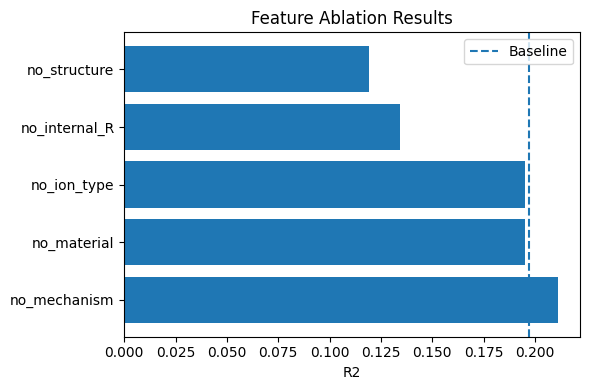

In [17]:
# 建议画图（很有说服力）
plt.figure(figsize=(6,4))

plt.barh(ablation_df["Setting"], ablation_df["R2_mean"])
plt.axvline(baseline_mean, linestyle="--", label="Baseline")

plt.xlabel("R2")
plt.title("Feature Ablation Results")
plt.legend()
plt.tight_layout()
plt.show()

Feature ablation analysis reveals that both structural descriptors and internal resistance play dominant roles in model performance. Removing structure-related features leads to the largest performance degradation, followed by internal resistance, indicating their critical importance in governing system behavior.

In contrast, removing ion type or material class results in negligible changes, suggesting that these coarse-grained descriptors provide limited additional information in the current dataset.

Notably, removing mechanistic labels slightly improves performance, implying that these labels may introduce noise or inconsistency rather than meaningful predictive information. This highlights the limitations of manually assigned mechanism categories in complex hydrovoltaic systems.

## 05.4 Sensitivity to target definition (Target ablation)

We evaluate whether the modeling conclusions depend on the choice of target variable by comparing model performance across different physical outputs, including voltage (Voc), current density (Jsc), and estimated power density.

In [20]:
# 定义 targets（注意对数）
df_robust = df.dropna(subset=[TARGET, STRATIFY_COL]).copy()
X = df_robust[FEATURES_MODEL_B]
y = df_robust[TARGET]

In [23]:
# 定义 targets（安全版本）
# 定义 targets（统一基于 df_robust）

targets = {
    "log_power": df_robust[TARGET],
    
    # ⚠️ 如果你的列名不是 "Voc"，请改成实际列名
    "Voc": df_robust["voc_V"],
    
    # ⚠️ 防止 log(0)
    "log_Jsc": np.log(df_robust["jsc_uA_cm2"].clip(lower=1e-9))
}

# 检查一下有没有 NaN / inf
for k, v in targets.items():
    print(k, "NaN:", v.isna().sum(), "Inf:", np.isinf(v).sum())

log_power NaN: 0 Inf: 0
Voc NaN: 0 Inf: 0
log_Jsc NaN: 0 Inf: 0


In [24]:
# Target loop（核心）
target_results = []

for name, y_tmp in targets.items():
    
    # 注意：X不变，只换target
    rf_pipeline = build_rf_pipeline(df_robust, FEATURES_MODEL_B)
    
    scores = cross_validate(
        rf_pipeline,
        X,
        y_tmp,
        cv=sss.split(X, df_robust[STRATIFY_COL]),
        scoring="r2",
        n_jobs=-1
    )
    
    target_results.append({
        "Target": name,
        "R2_mean": scores["test_score"].mean(),
        "R2_std": scores["test_score"].std(),
        "R2_min": scores["test_score"].min(),
        "R2_max": scores["test_score"].max()
    })

target_df = pd.DataFrame(target_results)

target_df

,Target,R2_mean,R2_std,R2_min,R2_max
0,log_power,0.197305,0.154939,-0.166687,0.453084
1,Voc,-0.385838,0.607262,-2.583304,0.212640
2,log_Jsc,0.274758,0.146178,-0.125990,0.505627


In [25]:
# 排序 + 对比
target_df = target_df.sort_values("R2_mean", ascending=False)

target_df

,Target,R2_mean,R2_std,R2_min,R2_max
2,log_Jsc,0.274758,0.146178,-0.125990,0.505627
0,log_power,0.197305,0.154939,-0.166687,0.453084
1,Voc,-0.385838,0.607262,-2.583304,0.212640


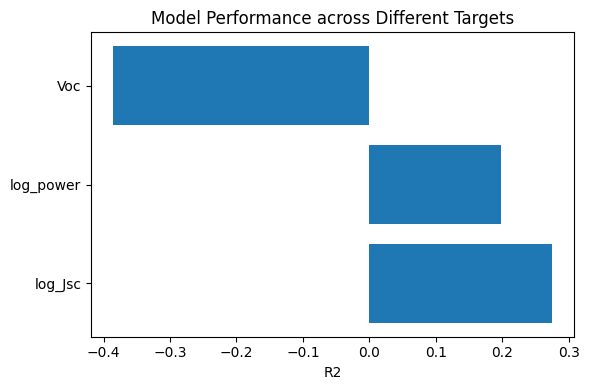

In [26]:
# 可视化（论文图）
plt.figure(figsize=(6,4))

plt.barh(target_df["Target"], target_df["R2_mean"])

plt.xlabel("R2")
plt.title("Model Performance across Different Targets")

plt.tight_layout()
plt.show()

Model performance strongly depends on the choice of target variable. The highest predictive accuracy is achieved for log-transformed current density (Jsc), while estimated power density shows moderate performance. In contrast, open-circuit voltage (Voc) is poorly predicted, with negative R² values and large variance across splits.

This indicates that the model primarily captures transport-driven processes, which are well represented by features such as structure and internal resistance. In contrast, Voc is influenced by complex interfacial and electrostatic effects that are not explicitly encoded in the dataset, making it inherently difficult to predict.

These results suggest that system-level transport properties are more amenable to data-driven modeling than voltage-related quantities in hydrovoltaic systems.

## 05.5 Mechanism subgroup modeling

We further evaluate whether model performance differs across mechanistic subgroups. This analysis tests whether different hydrovoltaic mechanisms show different levels of predictability.

In [27]:
# 查看 subgroup 数量
df_robust[STRATIFY_COL].value_counts(dropna=False)

mechanism_simple
ion_gradient    107
streaming        52
Name: count, dtype: int64

In [28]:
# subgroup evaluation function
def evaluate_subgroup_cv(df_input, mechanism_value, features, target):
    df_sub = df_input[df_input[STRATIFY_COL] == mechanism_value].copy()
    
    X_sub = df_sub[features]
    y_sub = df_sub[target]
    
    # 小子集不适合太多split
    cv = StratifiedShuffleSplit(
        n_splits=50,
        test_size=0.2,
        random_state=42
    )
    
    # subgroup内部无法再按mechanism分层，所以用一个dummy strata
    dummy_strata = np.zeros(len(df_sub))
    
    pipe = build_rf_pipeline(df_sub, features)
    
    scores = cross_validate(
        pipe,
        X_sub,
        y_sub,
        cv=cv.split(X_sub, dummy_strata),
        scoring="r2",
        n_jobs=-1
    )
    
    return {
        "Mechanism": mechanism_value,
        "Rows": len(df_sub),
        "R2_mean": scores["test_score"].mean(),
        "R2_std": scores["test_score"].std(),
        "R2_min": scores["test_score"].min(),
        "R2_max": scores["test_score"].max()
    }

In [29]:
# 跑 subgroup
mechanism_values = df_robust[STRATIFY_COL].dropna().unique()

subgroup_results = []

for mech in mechanism_values:
    result = evaluate_subgroup_cv(
        df_input=df_robust,
        mechanism_value=mech,
        features=FEATURES_MODEL_B,
        target=TARGET
    )
    subgroup_results.append(result)

subgroup_df = pd.DataFrame(subgroup_results).sort_values("R2_mean", ascending=False)

subgroup_df

,Mechanism,Rows,R2_mean,R2_std,R2_min,R2_max
1,ion_gradient,107,0.004680,0.247485,-0.749890,0.353201
0,streaming,52,-0.756644,0.529685,-2.448026,0.115717


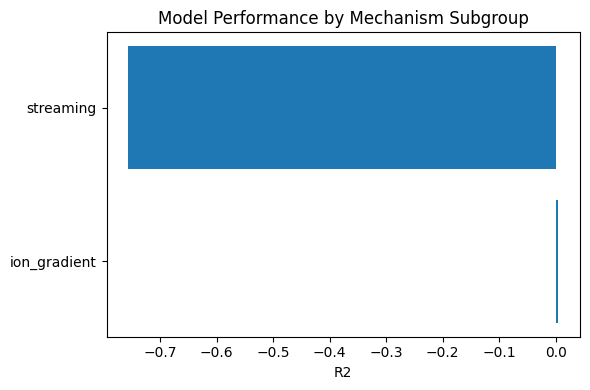

In [30]:
# 画图
plt.figure(figsize=(6,4))

plt.barh(subgroup_df["Mechanism"], subgroup_df["R2_mean"])

plt.xlabel("R2")
plt.title("Model Performance by Mechanism Subgroup")

plt.tight_layout()
plt.show()

In [31]:
# 保存结果
subgroup_df.to_csv(
    "../results/phase2_mechanism_subgroup_results.csv",
    index=False,
    encoding="utf-8-sig"
)

Mechanism subgroup modeling reveals a striking contrast with the global model. When restricted to individual mechanisms, model performance collapses, with R² ≈ 0 for ion-gradient systems and strongly negative values for streaming systems.

This indicates that the predictive signal observed in the full dataset primarily arises from differences between mechanisms, rather than variations within each mechanism. In particular, the poor performance within the streaming subset suggests that the assigned mechanism labels may be inconsistent or fail to capture the underlying physical processes.

These findings highlight the limitations of discrete mechanism classification and suggest that continuous descriptors such as structure and internal resistance provide a more reliable representation of hydrovoltaic system behavior.

# Hydrovoltaic performance is governed by continuous transport-related descriptors rather than discrete mechanism labels.